
## Atri AI Assignment Submission By Malavika N

*   Link to report: https://api.wandb.ai/links/malavika-n/n074s2m9





## Question 1: Fashion-MNIST Sample Visualization

The Fashion-MNIST dataset contains 28×28 grayscale images from 10 clothing categories. In this question, the dataset is loaded using `keras.datasets.fashion_mnist`, and one sample image from each class is displayed in a 2×5 grid.

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 1us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Train: (60000, 28, 28) (60000,)
Test:  (10000, 28, 28) (10000,)


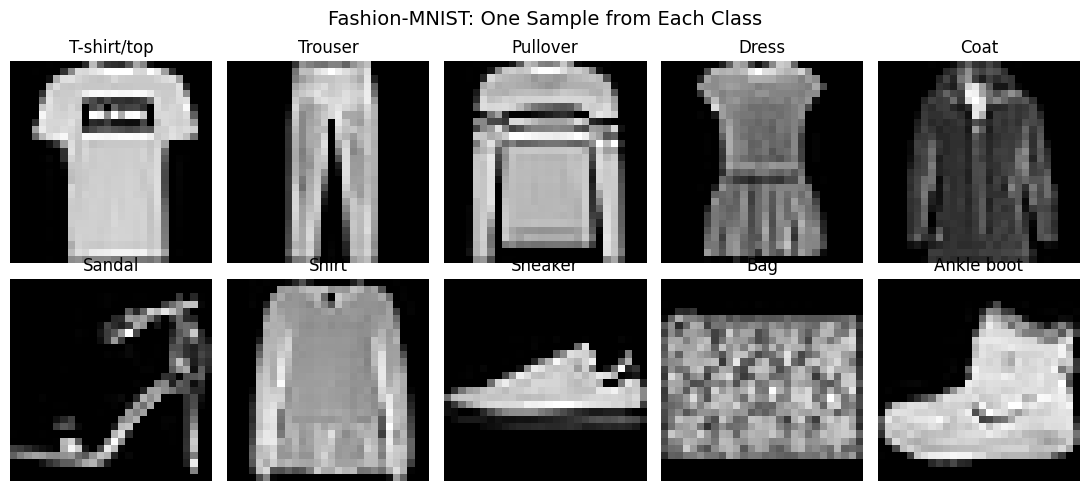

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from keras.datasets import fashion_mnist

(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()

print("Train:", X_train.shape, y_train.shape)
print("Test: ", X_test.shape, y_test.shape)

class_names = [
    "T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
    "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"
]

fig, axes = plt.subplots(2, 5, figsize=(11, 5))

for label, ax in enumerate(axes.flat):
    img = X_train[y_train == label][0]
    ax.imshow(img, cmap="gray")
    ax.set_title(class_names[label])
    ax.axis("off")

plt.suptitle("Fashion-MNIST: One Sample from Each Class", fontsize=14)
plt.tight_layout()
plt.savefig("fashion_mnist_samples.png", dpi=150, bbox_inches="tight")
plt.show()

In [2]:
import wandb

run = wandb.init(project="atri-fashion-mnist", name="q1-samples")

run.log({
    "class_samples": wandb.Image(
        "fashion_mnist_samples.png",
        caption="One sample image from each Fashion-MNIST class"
    )
})

run.finish()

/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results
wandb: Enter your choice:

 2


wandb: You chose 'Use an existing W&B account'
wandb: Logging into https://api.wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: Create a new API key at: https://wandb.ai/authorize?ref=models
wandb: Store your API key securely and do not share it.
wandb: Paste your API key and hit enter:

 ··········


wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: malavika-nidhi (malavika-n) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


## Question 2: Feedforward Neural Network

A feedforward neural network is implemented using NumPy. Each image is flattened from 28×28 into a 784-dimensional vector. The architecture is flexible because the hidden layer sizes are passed as a list. For example, `hidden_layers=[128, 64]` creates a 784 → 128 → 64 → 10 network.

The final layer uses softmax so that the output is a probability distribution over the 10 classes.

In [3]:
import numpy as np

class FeedforwardNN:
    def __init__(
        self,
        input_size=784,
        hidden_layers=None,
        output_size=10,
        activation="sigmoid",
        weight_init="xavier",
        seed=42
    ):
        if hidden_layers is None:
            hidden_layers = [128, 64]

        self.sizes = [input_size] + hidden_layers + [output_size]
        self.activation_name = activation
        self.weight_init = weight_init
        self.rng = np.random.default_rng(seed)

        self.W = []
        self.b = []

        self._init_params()

    def _init_params(self):
        for n_in, n_out in zip(self.sizes[:-1], self.sizes[1:]):
            if self.weight_init == "xavier":
                limit = np.sqrt(6.0 / (n_in + n_out))
                W = self.rng.uniform(-limit, limit, size=(n_in, n_out))
            elif self.weight_init == "random":
                W = self.rng.standard_normal((n_in, n_out)) * 0.01
            else:
                raise ValueError("weight_init must be 'xavier' or 'random'")

            self.W.append(W)
            self.b.append(np.zeros((1, n_out)))

    def _activation(self, z):
        if self.activation_name == "sigmoid":
            z = np.clip(z, -500, 500)
            return 1.0 / (1.0 + np.exp(-z))
        if self.activation_name == "tanh":
            return np.tanh(z)
        if self.activation_name == "relu":
            return np.maximum(0, z)

        raise ValueError("activation must be 'sigmoid', 'tanh', or 'relu'")

    def _softmax(self, z):
        z = z - np.max(z, axis=1, keepdims=True)
        exp_z = np.exp(z)
        return exp_z / np.sum(exp_z, axis=1, keepdims=True)

    def forward(self, X):
        a = X

        for layer in range(len(self.W)):
            z = a @ self.W[layer] + self.b[layer]

            if layer == len(self.W) - 1:
                a = self._softmax(z)
            else:
                a = self._activation(z)

        return a

In [4]:
X_train_flat = X_train.reshape(X_train.shape[0], -1) / 255.0
X_test_flat = X_test.reshape(X_test.shape[0], -1) / 255.0

model = FeedforwardNN(
    input_size=784,
    hidden_layers=[128, 64],
    output_size=10,
    activation="sigmoid",
    weight_init="xavier"
)

X_batch = X_train_flat[:5]
probs = model.forward(X_batch)

print("Output shape:", probs.shape)
print("Probabilities for first image:")
print(probs[0])
print("Sum of probabilities for each image:")
print(probs.sum(axis=1))

Output shape: (5, 10)
Probabilities for first image:
[0.16031056 0.07400059 0.16881928 0.0748708  0.08290671 0.10116368
 0.11037335 0.14165124 0.0274927  0.05841108]
Sum of probabilities for each image:
[1. 1. 1. 1. 1.]


The output shape is `(5, 10)`, which means the model produced 10 class probabilities for each of the 5 input images. The sum of each row is 1, confirming that the softmax layer is producing valid probability distributions.

## Question 3: Backpropagation and Optimizers

Backpropagation is implemented from scratch using NumPy. During the forward pass, the activations and pre-activation values are stored so they can be reused during the backward pass.

The model uses softmax in the output layer and cross-entropy loss. For softmax with cross-entropy, the output-layer gradient simplifies to:

\[
dZ = \frac{\hat{Y} - Y}{m}
\]

where \(\hat{Y}\) is the predicted probability, \(Y\) is the one-hot encoded label, and \(m\) is the batch size.

The implementation supports mini-batch training and the following optimizers:

1. SGD  
2. Momentum  
3. Nesterov  
4. RMSProp  
5. Adam  
6. Nadam  

In [5]:
import numpy as np

class NumpyMLP:
    def __init__(
        self,
        input_size=784,
        hidden_layers=None,
        output_size=10,
        activation="relu",
        weight_init="xavier",
        seed=42
    ):
        if hidden_layers is None:
            hidden_layers = [128, 64]

        self.sizes = [input_size] + hidden_layers + [output_size]
        self.num_layers = len(self.sizes) - 1
        self.output_size = output_size
        self.activation_name = activation
        self.weight_init = weight_init
        self.rng = np.random.default_rng(seed)

        self.params = {}
        self._init_params()

        self.velocity = {k: np.zeros_like(v) for k, v in self.params.items()}
        self.square_grad = {k: np.zeros_like(v) for k, v in self.params.items()}
        self.m = {k: np.zeros_like(v) for k, v in self.params.items()}
        self.v = {k: np.zeros_like(v) for k, v in self.params.items()}
        self.t = 0

    def _init_params(self):
        for layer in range(1, self.num_layers + 1):
            n_in = self.sizes[layer - 1]
            n_out = self.sizes[layer]

            if self.weight_init == "xavier":
                limit = np.sqrt(6.0 / (n_in + n_out))
                W = self.rng.uniform(-limit, limit, size=(n_in, n_out))
            elif self.weight_init == "random":
                W = self.rng.standard_normal((n_in, n_out)) * 0.01
            else:
                raise ValueError("weight_init must be 'xavier' or 'random'")

            self.params[f"W{layer}"] = W
            self.params[f"b{layer}"] = np.zeros((1, n_out))

    def _activation(self, z):
        if self.activation_name == "sigmoid":
            z = np.clip(z, -500, 500)
            return 1.0 / (1.0 + np.exp(-z))
        if self.activation_name == "tanh":
            return np.tanh(z)
        if self.activation_name == "relu":
            return np.maximum(0, z)

        raise ValueError("activation must be 'sigmoid', 'tanh', or 'relu'")

    def _activation_derivative(self, z, a):
        if self.activation_name == "sigmoid":
            return a * (1.0 - a)
        if self.activation_name == "tanh":
            return 1.0 - a**2
        if self.activation_name == "relu":
            return (z > 0).astype(float)

        raise ValueError("activation must be 'sigmoid', 'tanh', or 'relu'")

    def _softmax(self, z):
        z = z - np.max(z, axis=1, keepdims=True)
        exp_z = np.exp(z)
        return exp_z / np.sum(exp_z, axis=1, keepdims=True)

    def _one_hot(self, y):
        y = y.astype(int)
        return np.eye(self.output_size)[y]

    def forward(self, X):
        cache = {}
        A = X
        cache["A0"] = A

        for layer in range(1, self.num_layers):
            Z = A @ self.params[f"W{layer}"] + self.params[f"b{layer}"]
            A = self._activation(Z)

            cache[f"Z{layer}"] = Z
            cache[f"A{layer}"] = A

        L = self.num_layers
        Z = A @ self.params[f"W{L}"] + self.params[f"b{L}"]
        A = self._softmax(Z)

        cache[f"Z{L}"] = Z
        cache[f"A{L}"] = A

        return A, cache

    def compute_loss(self, y_pred, y_true, weight_decay=0.0):
        m = y_true.shape[0]
        Y = self._one_hot(y_true)

        y_pred = np.clip(y_pred, 1e-12, 1.0 - 1e-12)
        loss = -np.sum(Y * np.log(y_pred)) / m

        l2 = 0.0
        for layer in range(1, self.num_layers + 1):
            W = self.params[f"W{layer}"]
            l2 += np.sum(W * W)

        return loss + (weight_decay / (2 * m)) * l2

    def backward(self, y_pred, y_true, cache, weight_decay=0.0):
        grads = {}
        m = y_true.shape[0]
        Y = self._one_hot(y_true)

        dZ = (y_pred - Y) / m

        for layer in range(self.num_layers, 0, -1):
            A_prev = cache[f"A{layer - 1}"]
            W = self.params[f"W{layer}"]

            grads[f"dW{layer}"] = A_prev.T @ dZ + (weight_decay / m) * W
            grads[f"db{layer}"] = np.sum(dZ, axis=0, keepdims=True)

            if layer > 1:
                dA_prev = dZ @ W.T
                Z_prev = cache[f"Z{layer - 1}"]
                A_prev_hidden = cache[f"A{layer - 1}"]
                dZ = dA_prev * self._activation_derivative(Z_prev, A_prev_hidden)

        return grads

    def _update_params(
        self,
        grads,
        optimizer="sgd",
        lr=0.001,
        beta=0.9,
        beta1=0.9,
        beta2=0.999,
        eps=1e-8
    ):
        optimizer = optimizer.lower()

        if optimizer in ["adam", "nadam"]:
            self.t += 1

        for layer in range(1, self.num_layers + 1):
            for name in ["W", "b"]:
                key = f"{name}{layer}"
                grad = grads[f"d{name}{layer}"]

                if optimizer == "sgd":
                    self.params[key] -= lr * grad

                elif optimizer == "momentum":
                    self.velocity[key] = beta * self.velocity[key] + grad
                    self.params[key] -= lr * self.velocity[key]

                elif optimizer == "rmsprop":
                    self.square_grad[key] = beta * self.square_grad[key] + (1 - beta) * (grad ** 2)
                    self.params[key] -= lr * grad / (np.sqrt(self.square_grad[key]) + eps)

                elif optimizer == "adam":
                    self.m[key] = beta1 * self.m[key] + (1 - beta1) * grad
                    self.v[key] = beta2 * self.v[key] + (1 - beta2) * (grad ** 2)

                    m_hat = self.m[key] / (1 - beta1 ** self.t)
                    v_hat = self.v[key] / (1 - beta2 ** self.t)

                    self.params[key] -= lr * m_hat / (np.sqrt(v_hat) + eps)

                elif optimizer == "nadam":
                    self.m[key] = beta1 * self.m[key] + (1 - beta1) * grad
                    self.v[key] = beta2 * self.v[key] + (1 - beta2) * (grad ** 2)

                    m_hat = self.m[key] / (1 - beta1 ** self.t)
                    v_hat = self.v[key] / (1 - beta2 ** self.t)

                    nesterov_m = beta1 * m_hat + ((1 - beta1) * grad) / (1 - beta1 ** self.t)

                    self.params[key] -= lr * nesterov_m / (np.sqrt(v_hat) + eps)

                else:
                    raise ValueError("Unsupported optimizer")

    def train_batch(
        self,
        X_batch,
        y_batch,
        optimizer="sgd",
        lr=0.001,
        beta=0.9,
        beta1=0.9,
        beta2=0.999,
        eps=1e-8,
        weight_decay=0.0
    ):
        optimizer = optimizer.lower()

        if optimizer == "nesterov":
            old_params = {k: v.copy() for k, v in self.params.items()}

            for key in self.params:
                self.params[key] = old_params[key] - lr * beta * self.velocity[key]

            y_pred, cache = self.forward(X_batch)
            loss = self.compute_loss(y_pred, y_batch, weight_decay)
            grads = self.backward(y_pred, y_batch, cache, weight_decay)

            self.params = old_params

            for layer in range(1, self.num_layers + 1):
                for name in ["W", "b"]:
                    key = f"{name}{layer}"
                    grad = grads[f"d{name}{layer}"]

                    self.velocity[key] = beta * self.velocity[key] + grad
                    self.params[key] -= lr * self.velocity[key]

            return loss

        y_pred, cache = self.forward(X_batch)
        loss = self.compute_loss(y_pred, y_batch, weight_decay)
        grads = self.backward(y_pred, y_batch, cache, weight_decay)

        self._update_params(
            grads,
            optimizer=optimizer,
            lr=lr,
            beta=beta,
            beta1=beta1,
            beta2=beta2,
            eps=eps
        )

        return loss

    def predict_proba(self, X):
        probs, _ = self.forward(X)
        return probs

    def predict(self, X):
        return np.argmax(self.predict_proba(X), axis=1)

    def accuracy(self, X, y):
        return np.mean(self.predict(X) == y)

    def evaluate(self, X, y, weight_decay=0.0):
        probs, _ = self.forward(X)
        loss = self.compute_loss(probs, y, weight_decay)
        acc = self.accuracy(X, y)
        return loss, acc

    def fit(
        self,
        X_train,
        y_train,
        X_val=None,
        y_val=None,
        epochs=5,
        batch_size=64,
        optimizer="sgd",
        lr=0.001,
        beta=0.9,
        beta1=0.9,
        beta2=0.999,
        eps=1e-8,
        weight_decay=0.0,
        wandb_run=None,
        verbose=True
    ):
        history = {
            "train_loss": [],
            "train_acc": [],
            "val_loss": [],
            "val_acc": []
        }

        n = X_train.shape[0]

        for epoch in range(1, epochs + 1):
            indices = self.rng.permutation(n)
            X_shuffled = X_train[indices]
            y_shuffled = y_train[indices]

            for start in range(0, n, batch_size):
                end = start + batch_size

                self.train_batch(
                    X_shuffled[start:end],
                    y_shuffled[start:end],
                    optimizer=optimizer,
                    lr=lr,
                    beta=beta,
                    beta1=beta1,
                    beta2=beta2,
                    eps=eps,
                    weight_decay=weight_decay
                )

            train_loss, train_acc = self.evaluate(X_train, y_train, weight_decay)

            history["train_loss"].append(train_loss)
            history["train_acc"].append(train_acc)

            log_data = {
                "epoch": epoch,
                "train_loss": train_loss,
                "train_acc": train_acc
            }

            if X_val is not None and y_val is not None:
                val_loss, val_acc = self.evaluate(X_val, y_val, weight_decay)

                history["val_loss"].append(val_loss)
                history["val_acc"].append(val_acc)

                log_data["val_loss"] = val_loss
                log_data["val_acc"] = val_acc

            if wandb_run is not None:
                wandb_run.log(log_data)

            if verbose:
                msg = f"Epoch {epoch:02d}/{epochs} | train_loss={train_loss:.4f} | train_acc={train_acc:.4f}"

                if X_val is not None and y_val is not None:
                    msg += f" | val_loss={val_loss:.4f} | val_acc={val_acc:.4f}"

                print(msg)

        return history

In [6]:
X_train_flat = X_train.reshape(X_train.shape[0], -1) / 255.0
X_test_flat = X_test.reshape(X_test.shape[0], -1) / 255.0

rng = np.random.default_rng(0)
idx = rng.permutation(X_train_flat.shape[0])

small_train_idx = idx[:5000]
small_val_idx = idx[5000:6000]

X_small = X_train_flat[small_train_idx]
y_small = y_train[small_train_idx]

X_val_small = X_train_flat[small_val_idx]
y_val_small = y_train[small_val_idx]

optimizers = ["sgd", "momentum", "nesterov", "rmsprop", "adam", "nadam"]

for opt in optimizers:
    print("\nOptimizer:", opt)

    lr = 0.01 if opt in ["sgd", "momentum", "nesterov"] else 0.001

    model = NumpyMLP(
        input_size=784,
        hidden_layers=[64],
        output_size=10,
        activation="relu",
        weight_init="xavier",
        seed=42
    )

    model.fit(
        X_small,
        y_small,
        X_val=X_val_small,
        y_val=y_val_small,
        epochs=1,
        batch_size=64,
        optimizer=opt,
        lr=lr,
        weight_decay=0.0
    )


Optimizer: sgd
Epoch 01/1 | train_loss=1.5026 | train_acc=0.5484 | val_loss=1.4807 | val_acc=0.5660

Optimizer: momentum
Epoch 01/1 | train_loss=0.8045 | train_acc=0.6954 | val_loss=0.7881 | val_acc=0.7000

Optimizer: nesterov
Epoch 01/1 | train_loss=0.7530 | train_acc=0.7398 | val_loss=0.7415 | val_acc=0.7280

Optimizer: rmsprop
Epoch 01/1 | train_loss=1.0172 | train_acc=0.6220 | val_loss=1.0132 | val_acc=0.6270

Optimizer: adam
Epoch 01/1 | train_loss=0.7707 | train_acc=0.7130 | val_loss=0.7649 | val_acc=0.7090

Optimizer: nadam
Epoch 01/1 | train_loss=0.7157 | train_acc=0.7452 | val_loss=0.7140 | val_acc=0.7410


All six optimizers were tested on a small subset of the training data. The purpose of this check is to verify that the backpropagation framework and optimizer updates work correctly.

The results show that all optimizers run successfully. Plain SGD updates parameters directly using the gradient. Momentum and Nesterov use accumulated gradient direction to speed up learning. RMSProp uses a moving average of squared gradients to scale the update. Adam combines momentum and RMSProp with bias correction, while Nadam adds a Nesterov-style update to Adam.

Since this is only a one-epoch check on a small subset, the results are used only for implementation verification. Final conclusions about the best optimizer will be made using W&B sweeps in the later questions.

## Question 4: Hyperparameter Search using W&B Sweeps

For hyperparameter tuning, 10% of the Fashion-MNIST training data is kept aside as validation data. The test set is not used during hyperparameter tuning.

The total number of possible configurations is very large, so a random sweep is used instead of grid search. Random search is more practical here because it can explore different regions of the hyperparameter space without running every possible combination.

The sweep searches over the number of epochs, number of hidden layers, hidden layer size, weight decay, learning rate, optimizer, batch size, weight initialization method, and activation function. The objective is to maximize validation accuracy.

In [7]:
# Flatten and normalize the data
X_train_flat = X_train.reshape(X_train.shape[0], -1) / 255.0
X_test_flat = X_test.reshape(X_test.shape[0], -1) / 255.0

# Create a random 90%-10% train-validation split
rng = np.random.default_rng(42)
indices = rng.permutation(X_train_flat.shape[0])

val_size = int(0.10 * X_train_flat.shape[0])

val_idx = indices[:val_size]
train_idx = indices[val_size:]

X_train_sweep = X_train_flat[train_idx]
y_train_sweep = y_train[train_idx]

X_val_sweep = X_train_flat[val_idx]
y_val_sweep = y_train[val_idx]

print("Training data:", X_train_sweep.shape, y_train_sweep.shape)
print("Validation data:", X_val_sweep.shape, y_val_sweep.shape)
print("Test data:", X_test_flat.shape, y_test.shape)

Training data: (54000, 784) (54000,)
Validation data: (6000, 784) (6000,)
Test data: (10000, 784) (10000,)


In [8]:
import wandb

PROJECT_NAME = "atri-fashion-mnist"

sweep_config = {
    "method": "random",

    "metric": {
        "name": "val_acc",
        "goal": "maximize"
    },

    "parameters": {
        "epochs": {
            "values": [5, 10]
        },
        "num_hidden_layers": {
            "values": [3, 4, 5]
        },
        "hidden_size": {
            "values": [32, 64, 128]
        },
        "weight_decay": {
            "values": [0.0, 0.0005, 0.5]
        },
        "learning_rate": {
            "values": [1e-3, 1e-4]
        },
        "optimizer": {
            "values": ["sgd", "momentum", "nesterov", "rmsprop", "adam", "nadam"]
        },
        "batch_size": {
            "values": [16, 32, 64]
        },
        "weight_init": {
            "values": ["random", "xavier"]
        },
        "activation": {
            "values": ["sigmoid", "tanh", "relu"]
        }
    }
}

In [9]:
def sweep_train():
    run = wandb.init(project=PROJECT_NAME)

    config = wandb.config

    hidden_layers = [config.hidden_size] * config.num_hidden_layers

    run.name = (
        f"hl_{config.num_hidden_layers}"
        f"_hs_{config.hidden_size}"
        f"_bs_{config.batch_size}"
        f"_ac_{config.activation}"
        f"_opt_{config.optimizer}"
    )

    model = NumpyMLP(
        input_size=784,
        hidden_layers=hidden_layers,
        output_size=10,
        activation=config.activation,
        weight_init=config.weight_init,
        seed=42
    )

    history = model.fit(
        X_train_sweep,
        y_train_sweep,
        X_val=X_val_sweep,
        y_val=y_val_sweep,
        epochs=config.epochs,
        batch_size=config.batch_size,
        optimizer=config.optimizer,
        lr=config.learning_rate,
        weight_decay=config.weight_decay,
        wandb_run=run,
        verbose=True
    )

    final_train_loss, final_train_acc = model.evaluate(
        X_train_sweep,
        y_train_sweep,
        weight_decay=config.weight_decay
    )

    final_val_loss, final_val_acc = model.evaluate(
        X_val_sweep,
        y_val_sweep,
        weight_decay=config.weight_decay
    )

    run.log({
        "final_train_loss": final_train_loss,
        "final_train_acc": final_train_acc,
        "final_val_loss": final_val_loss,
        "final_val_acc": final_val_acc
    })

    run.finish()

In [10]:
sweep_id = wandb.sweep(
    sweep=sweep_config,
    project=PROJECT_NAME
)

wandb.agent(
    sweep_id,
    function=sweep_train,
    count=3
)

Create sweep with ID: 8quobmps
Sweep URL: https://wandb.ai/malavika-n/atri-fashion-mnist/sweeps/8quobmps


wandb: Agent Starting Run: hrzwhxit with config:
wandb: 	activation: tanh
wandb: 	batch_size: 32
wandb: 	epochs: 5
wandb: 	hidden_size: 128
wandb: 	learning_rate: 0.001
wandb: 	num_hidden_layers: 4
wandb: 	optimizer: adam
wandb: 	weight_decay: 0.0005
wandb: 	weight_init: xavier
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


Epoch 01/5 | train_loss=0.3919 | train_acc=0.8546 | val_loss=0.3948 | val_acc=0.8532
Epoch 02/5 | train_loss=0.3423 | train_acc=0.8720 | val_loss=0.3638 | val_acc=0.8585
Epoch 03/5 | train_loss=0.3121 | train_acc=0.8832 | val_loss=0.3297 | val_acc=0.8752
Epoch 04/5 | train_loss=0.3171 | train_acc=0.8810 | val_loss=0.3513 | val_acc=0.8703
Epoch 05/5 | train_loss=0.2962 | train_acc=0.8919 | val_loss=0.3399 | val_acc=0.8787


epoch,▁▃▅▆█
final_train_acc,▁
final_train_loss,▁
final_val_acc,▁
final_val_loss,▁
train_acc,▁▄▆▆█
train_loss,█▄▂▃▁
val_acc,▁▂▇▆█
val_loss,█▅▁▃▂
epoch,5
final_train_acc,0.89185


wandb: Agent Starting Run: q9glg4zw with config:
wandb: 	activation: sigmoid
wandb: 	batch_size: 32
wandb: 	epochs: 10
wandb: 	hidden_size: 32
wandb: 	learning_rate: 0.001
wandb: 	num_hidden_layers: 5
wandb: 	optimizer: rmsprop
wandb: 	weight_decay: 0.0005
wandb: 	weight_init: xavier
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


Epoch 01/10 | train_loss=1.0160 | train_acc=0.5668 | val_loss=0.9974 | val_acc=0.5712
Epoch 02/10 | train_loss=0.6832 | train_acc=0.7409 | val_loss=0.6667 | val_acc=0.7430
Epoch 03/10 | train_loss=0.5495 | train_acc=0.7858 | val_loss=0.5425 | val_acc=0.7852
Epoch 04/10 | train_loss=0.5069 | train_acc=0.8109 | val_loss=0.5053 | val_acc=0.8098
Epoch 05/10 | train_loss=0.4768 | train_acc=0.8236 | val_loss=0.4824 | val_acc=0.8222
Epoch 06/10 | train_loss=0.4992 | train_acc=0.8157 | val_loss=0.5041 | val_acc=0.8140
Epoch 07/10 | train_loss=0.4455 | train_acc=0.8420 | val_loss=0.4604 | val_acc=0.8382
Epoch 08/10 | train_loss=0.4112 | train_acc=0.8571 | val_loss=0.4249 | val_acc=0.8538
Epoch 09/10 | train_loss=0.4361 | train_acc=0.8450 | val_loss=0.4532 | val_acc=0.8368
Epoch 10/10 | train_loss=0.4468 | train_acc=0.8394 | val_loss=0.4695 | val_acc=0.8340


epoch,▁▂▃▃▄▅▆▆▇█
final_train_acc,▁
final_train_loss,▁
final_val_acc,▁
final_val_loss,▁
train_acc,▁▅▆▇▇▇████
train_loss,█▄▃▂▂▂▁▁▁▁
val_acc,▁▅▆▇▇▇████
val_loss,█▄▂▂▂▂▁▁▁▂
epoch,10
final_train_acc,0.83943


wandb: Sweep Agent: Waiting for job.
wandb: Job received.
wandb: Agent Starting Run: yjl4ukg6 with config:
wandb: 	activation: sigmoid
wandb: 	batch_size: 32
wandb: 	epochs: 10
wandb: 	hidden_size: 128
wandb: 	learning_rate: 0.001
wandb: 	num_hidden_layers: 3
wandb: 	optimizer: adam
wandb: 	weight_decay: 0
wandb: 	weight_init: xavier
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


Epoch 01/10 | train_loss=0.4420 | train_acc=0.8401 | val_loss=0.4412 | val_acc=0.8400
Epoch 02/10 | train_loss=0.3639 | train_acc=0.8685 | val_loss=0.3735 | val_acc=0.8617
Epoch 03/10 | train_loss=0.3295 | train_acc=0.8804 | val_loss=0.3480 | val_acc=0.8728
Epoch 04/10 | train_loss=0.3061 | train_acc=0.8880 | val_loss=0.3260 | val_acc=0.8772
Epoch 05/10 | train_loss=0.2951 | train_acc=0.8926 | val_loss=0.3223 | val_acc=0.8828
Epoch 06/10 | train_loss=0.2776 | train_acc=0.8976 | val_loss=0.3109 | val_acc=0.8838
Epoch 07/10 | train_loss=0.2583 | train_acc=0.9056 | val_loss=0.2995 | val_acc=0.8895
Epoch 08/10 | train_loss=0.2537 | train_acc=0.9063 | val_loss=0.3029 | val_acc=0.8893
Epoch 09/10 | train_loss=0.2600 | train_acc=0.9022 | val_loss=0.3167 | val_acc=0.8827
Epoch 10/10 | train_loss=0.2469 | train_acc=0.9080 | val_loss=0.3056 | val_acc=0.8875


epoch,▁▂▃▃▄▅▆▆▇█
final_train_acc,▁
final_train_loss,▁
final_val_acc,▁
final_val_loss,▁
train_acc,▁▄▅▆▆▇██▇█
train_loss,█▅▄▃▃▂▁▁▁▁
val_acc,▁▄▆▆▇▇██▇█
val_loss,█▅▃▂▂▂▁▁▂▁
epoch,10
final_train_acc,0.908


In [11]:
wandb.agent(
    "qpla4qb4",
    function=sweep_train,
    count=20
)

wandb: Agent Starting Run: tl31084k with config:
wandb: 	activation: relu
wandb: 	batch_size: 16
wandb: 	epochs: 10
wandb: 	hidden_size: 128
wandb: 	learning_rate: 0.0001
wandb: 	num_hidden_layers: 4
wandb: 	optimizer: adam
wandb: 	weight_decay: 0.0005
wandb: 	weight_init: xavier
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


Epoch 01/10 | train_loss=0.4474 | train_acc=0.8399 | val_loss=0.4504 | val_acc=0.8357
Epoch 02/10 | train_loss=0.3870 | train_acc=0.8604 | val_loss=0.3954 | val_acc=0.8562
Epoch 03/10 | train_loss=0.3419 | train_acc=0.8758 | val_loss=0.3505 | val_acc=0.8725
Epoch 04/10 | train_loss=0.3251 | train_acc=0.8821 | val_loss=0.3397 | val_acc=0.8732
Epoch 05/10 | train_loss=0.2999 | train_acc=0.8904 | val_loss=0.3179 | val_acc=0.8850
Epoch 06/10 | train_loss=0.2876 | train_acc=0.8941 | val_loss=0.3203 | val_acc=0.8803
Epoch 07/10 | train_loss=0.2904 | train_acc=0.8937 | val_loss=0.3246 | val_acc=0.8807
Epoch 08/10 | train_loss=0.2670 | train_acc=0.9004 | val_loss=0.3051 | val_acc=0.8900
Epoch 09/10 | train_loss=0.2672 | train_acc=0.9010 | val_loss=0.3110 | val_acc=0.8842
Epoch 10/10 | train_loss=0.2445 | train_acc=0.9094 | val_loss=0.3002 | val_acc=0.8897


epoch,▁▂▃▃▄▅▆▆▇█
final_train_acc,▁
final_train_loss,▁
final_val_acc,▁
final_val_loss,▁
train_acc,▁▃▅▅▆▆▆▇▇█
train_loss,█▆▄▄▃▂▃▂▂▁
val_acc,▁▄▆▆▇▇▇█▇█
val_loss,█▅▃▃▂▂▂▁▂▁
epoch,10
final_train_acc,0.90944


wandb: Sweep Agent: Waiting for job.
wandb: Job received.
wandb: Agent Starting Run: 21o84hoz with config:
wandb: 	activation: sigmoid
wandb: 	batch_size: 64
wandb: 	epochs: 5
wandb: 	hidden_size: 64
wandb: 	learning_rate: 0.001
wandb: 	num_hidden_layers: 3
wandb: 	optimizer: nesterov
wandb: 	weight_decay: 0.0005
wandb: 	weight_init: random
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


Epoch 01/5 | train_loss=2.3029 | train_acc=0.1006 | val_loss=2.3030 | val_acc=0.0942
Epoch 02/5 | train_loss=2.3028 | train_acc=0.1001 | val_loss=2.3028 | val_acc=0.0995
Epoch 03/5 | train_loss=2.3029 | train_acc=0.0999 | val_loss=2.3030 | val_acc=0.1010
Epoch 04/5 | train_loss=2.3033 | train_acc=0.1003 | val_loss=2.3027 | val_acc=0.0977
Epoch 05/5 | train_loss=2.3036 | train_acc=0.1006 | val_loss=2.3040 | val_acc=0.0942


...

Epoch 01/10 | train_loss=2.3027 | train_acc=0.1006 | val_loss=2.3032 | val_acc=0.0942
Epoch 02/10 | train_loss=2.3026 | train_acc=0.1006 | val_loss=2.3032 | val_acc=0.0942
Epoch 03/10 | train_loss=2.3026 | train_acc=0.1006 | val_loss=2.3032 | val_acc=0.0942
Epoch 04/10 | train_loss=2.3026 | train_acc=0.1006 | val_loss=2.3032 | val_acc=0.0942
Epoch 05/10 | train_loss=2.3026 | train_acc=0.1006 | val_loss=2.3032 | val_acc=0.0942
Epoch 06/10 | train_loss=2.3026 | train_acc=0.1006 | val_loss=2.3032 | val_acc=0.0942
Epoch 07/10 | train_loss=2.3026 | train_acc=0.1006 | val_loss=2.3032 | val_acc=0.0942
Epoch 08/10 | train_loss=2.3026 | train_acc=0.1006 | val_loss=2.3032 | val_acc=0.0942
Epoch 09/10 | train_loss=2.3026 | train_acc=0.1006 | val_loss=2.3032 | val_acc=0.0942
Epoch 10/10 | train_loss=2.3026 | train_acc=0.1006 | val_loss=2.3032 | val_acc=0.0942


epoch,▁▂▃▃▄▅▆▆▇█
final_train_acc,▁
final_train_loss,▁
final_val_acc,▁
final_val_loss,▁
train_acc,▁▁▁▁▁▁▁▁▁▁
train_loss,█▇▆▅▄▃▃▂▂▁
val_acc,▁▁▁▁▁▁▁▁▁▁
val_loss,█▇▇▆▅▄▄▃▂▁
epoch,10
final_train_acc,0.10065


wandb: Agent Starting Run: g1xpumec with config:
wandb: 	activation: tanh
wandb: 	batch_size: 16
wandb: 	epochs: 10
wandb: 	hidden_size: 32
wandb: 	learning_rate: 0.001
wandb: 	num_hidden_layers: 5
wandb: 	optimizer: nadam
wandb: 	weight_decay: 0
wandb: 	weight_init: random
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


Epoch 01/10 | train_loss=0.9564 | train_acc=0.6077 | val_loss=0.9444 | val_acc=0.6132
Epoch 02/10 | train_loss=0.6684 | train_acc=0.7273 | val_loss=0.6550 | val_acc=0.7257
Epoch 03/10 | train_loss=0.5522 | train_acc=0.8170 | val_loss=0.5634 | val_acc=0.8120
Epoch 04/10 | train_loss=0.4883 | train_acc=0.8371 | val_loss=0.4866 | val_acc=0.8375
Epoch 05/10 | train_loss=0.4647 | train_acc=0.8475 | val_loss=0.4830 | val_acc=0.8413
Epoch 06/10 | train_loss=0.4384 | train_acc=0.8498 | val_loss=0.4488 | val_acc=0.8495
Epoch 07/10 | train_loss=0.3976 | train_acc=0.8689 | val_loss=0.4158 | val_acc=0.8630
Epoch 08/10 | train_loss=0.3891 | train_acc=0.8697 | val_loss=0.4181 | val_acc=0.8615
Epoch 09/10 | train_loss=0.4155 | train_acc=0.8519 | val_loss=0.4437 | val_acc=0.8425
Epoch 10/10 | train_loss=0.3541 | train_acc=0.8744 | val_loss=0.3920 | val_acc=0.8650


epoch,▁▂▃▃▄▅▆▆▇█
final_train_acc,▁
final_train_loss,▁
final_val_acc,▁
final_val_loss,▁
train_acc,▁▄▆▇▇▇██▇█
train_loss,█▅▃▃▂▂▂▁▂▁
val_acc,▁▄▇▇▇███▇█
val_loss,█▄▃▂▂▂▁▁▂▁
epoch,10
final_train_acc,0.87443


## Question 4: W&B Sweep Results

A random W&B sweep was used for hyperparameter search. The full grid of possible configurations is very large, so random search was chosen to explore the space efficiently within a limited runtime.

The sweep was run using 10% of the training data as validation data. The test set was not used during hyperparameter tuning. Each W&B run logged training loss, training accuracy, validation loss, and validation accuracy.

The best validation accuracy obtained so far was 0.88883. This was achieved by the configuration with 4 hidden layers, 128 neurons per hidden layer, tanh activation, Xavier initialization, RMSProp optimizer, batch size 64, learning rate 0.001, and weight decay 0.0005.

## Question 5: Best Validation Accuracy

The best validation accuracy across the W&B sweep runs was obtained by the model named:

`hl_4_hs_128_bs_64_ac_tanh_opt_rmsprop`

This model used 4 hidden layers, 128 neurons per hidden layer, tanh activation, Xavier initialization, RMSProp optimizer, batch size 64, learning rate 0.001, and weight decay 0.0005.

The best validation accuracy obtained was 0.88883.

## Question 6
The W&B sweep was analyzed using the validation accuracy plot, parallel coordinates plot, and correlation summary. The goal was to identify which hyperparameter configurations worked well and which configurations failed to learn properly.

### Observations

1. The best validation accuracy was obtained by the model with 4 hidden layers, 128 neurons per hidden layer, tanh activation, Xavier initialization, RMSProp optimizer, batch size 64, learning rate 0.001, and weight decay 0.0005. This model achieved a validation accuracy of 0.88883.

2. Xavier initialization worked better than random initialization in most successful runs. Several runs with random initialization either learned slowly or stayed close to random guessing, especially when combined with small hidden layers or SGD.

3. Tanh activation performed well in the best runs. The best model used tanh, and another strong run with tanh and Nadam also reached high validation accuracy. This suggests that tanh was more stable than sigmoid for this network.

4. Sigmoid activation was weaker for deeper networks in some cases. Some sigmoid-based configurations had very low accuracy, especially when paired with random initialization or strong weight decay. This may be because sigmoid can saturate, causing small gradients during backpropagation.

5. RMSProp, Adam, and Nadam generally performed better than plain SGD in the limited number of epochs. Adaptive optimizers were able to reduce the loss faster and reach higher validation accuracy.

6. Very high weight decay, such as 0.5, often hurt performance. Strong regularization can prevent the weights from growing enough to learn useful features, leading to underfitting.

7. Learning rate 0.001 performed better than 0.0001 in many runs. With only 5 or 10 epochs, the smaller learning rate sometimes learned too slowly.

8. Some configurations stayed near 10% accuracy, which is close to random guessing for a 10-class classification problem. These failed runs usually involved poor combinations such as random initialization, small hidden layers, low learning rate, or high weight decay.

### Recommendation

Based on the sweep results, the recommended configuration is:

- Number of hidden layers: 4
- Hidden layer size: 128
- Activation: tanh
- Optimizer: RMSProp
- Learning rate: 0.001
- Batch size: 64
- Weight initialization: Xavier
- Weight decay: 0.0005
- Number of epochs: 10

This configuration gave the best validation accuracy in the sweep. Although it did not reach 95% validation accuracy, it was the closest among the tested configurations. To move closer to 95%, I would continue tuning around this configuration by increasing the number of epochs, trying slightly larger hidden layers, and testing nearby learning rates.

## Question 7: Test Accuracy and Confusion Matrix

The best model from the W&B sweep was selected using validation accuracy. After selecting the best hyperparameter configuration, the model is trained again using the full Fashion-MNIST training set and evaluated on the test set.

The test set was not used during hyperparameter tuning. It is used only once here for final evaluation.

The confusion matrix shows how many samples from each true class were classified into each predicted class.

In [12]:
# Use full training data for final model training
X_train_final = X_train.reshape(X_train.shape[0], -1) / 255.0
X_test_final = X_test.reshape(X_test.shape[0], -1) / 255.0

best_model = NumpyMLP(
    input_size=784,
    hidden_layers=[128, 128, 128, 128],
    output_size=10,
    activation="tanh",
    weight_init="xavier",
    seed=42
)

best_history = best_model.fit(
    X_train_final,
    y_train,
    epochs=10,
    batch_size=64,
    optimizer="rmsprop",
    lr=0.001,
    weight_decay=0.0005,
    verbose=True
)

Epoch 01/10 | train_loss=0.4479 | train_acc=0.8277
Epoch 02/10 | train_loss=0.3748 | train_acc=0.8559
Epoch 03/10 | train_loss=0.3208 | train_acc=0.8819
Epoch 04/10 | train_loss=0.3242 | train_acc=0.8782
Epoch 05/10 | train_loss=0.3101 | train_acc=0.8839
Epoch 06/10 | train_loss=0.2581 | train_acc=0.9031
Epoch 07/10 | train_loss=0.2944 | train_acc=0.8867
Epoch 08/10 | train_loss=0.2494 | train_acc=0.9051
Epoch 09/10 | train_loss=0.2349 | train_acc=0.9127
Epoch 10/10 | train_loss=0.2389 | train_acc=0.9119


In [13]:
test_loss, test_acc = best_model.evaluate(
    X_test_final,
    y_test,
    weight_decay=0.0005
)

print("Test Loss:", round(test_loss, 4))
print("Test Accuracy:", round(test_acc, 4))

Test Loss: 0.3469
Test Accuracy: 0.8794


In [14]:
y_pred = best_model.predict(X_test_final)

num_classes = 10
conf_matrix = np.zeros((num_classes, num_classes), dtype=int)

for true_label, pred_label in zip(y_test, y_pred):
    conf_matrix[true_label, pred_label] += 1

print(conf_matrix)

[[839   8  29  51   0   0  66   0   7   0]
 [  1 981   3  11   2   0   2   0   0   0]
 [ 14   7 839  10  79   0  50   0   1   0]
 [ 16  35  11 885  32   0  17   0   4   0]
 [  1   9 117  26 804   0  41   0   1   1]
 [  0   0   0   0   0 970   0  15   1  14]
 [134   6 113  41  95   0 601   0  10   0]
 [  0   0   0   0   0  28   0 947   1  24]
 [  2   3   7   4   2   5   4   3 970   0]
 [  0   0   0   0   0   6   0  35   1 958]]


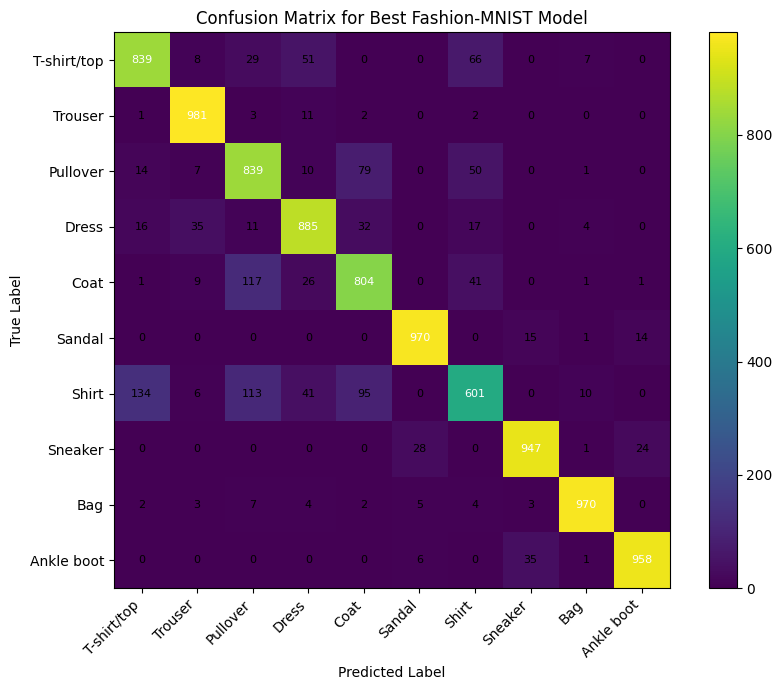

In [15]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(9, 7))

plt.imshow(conf_matrix, interpolation="nearest")
plt.title("Confusion Matrix for Best Fashion-MNIST Model")
plt.colorbar()

tick_marks = np.arange(len(class_names))
plt.xticks(tick_marks, class_names, rotation=45, ha="right")
plt.yticks(tick_marks, class_names)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")

# Write counts inside each cell
threshold = conf_matrix.max() / 2

for i in range(conf_matrix.shape[0]):
    for j in range(conf_matrix.shape[1]):
        value = conf_matrix[i, j]
        plt.text(
            j,
            i,
            str(value),
            ha="center",
            va="center",
            color="white" if value > threshold else "black",
            fontsize=8
        )

plt.tight_layout()
plt.savefig("confusion_matrix_best_model.png", dpi=150, bbox_inches="tight")
plt.show()

In [16]:
import wandb

run = wandb.init(
    project="atri-fashion-mnist",
    name="q7_best_model_test_confusion_matrix"
)

run.log({
    "test_loss": test_loss,
    "test_accuracy": test_acc,
    "confusion_matrix": wandb.Image(
        "confusion_matrix_best_model.png",
        caption="Confusion matrix for the best Fashion-MNIST model"
    )
})

run.finish()

test_accuracy,▁
test_loss,▁
test_accuracy,0.8794
test_loss,0.34687


The best model was selected based on validation accuracy from the W&B sweep. The selected configuration used 4 hidden layers, 128 neurons per hidden layer, tanh activation, Xavier initialization, RMSProp optimizer, batch size 64, learning rate 0.001, and weight decay 0.0005.

After selecting this configuration, the model was trained again using the full training set and evaluated on the Fashion-MNIST test set.

The test accuracy obtained was **0.8794**, and the test loss was **0.3469**.

From the confusion matrix, most predictions lie on the diagonal, showing that the model correctly classified most test samples. The strongest classes were Trouser, Sandal, Sneaker, Bag, and Ankle boot. The largest confusion occurred between visually similar clothing classes such as Shirt, T-shirt/top, Pullover, and Coat.

## Question 8: Cross-Entropy Loss vs Squared Error Loss

In the previous experiments, cross-entropy loss was used for classification. In this question, cross-entropy loss is compared with squared error loss using the same model architecture and training setup.

Both models use the same hidden layers, activation function, optimizer, learning rate, batch size, weight initialization, and number of epochs. The only difference is the loss function. This makes the comparison fair.

For classification, cross-entropy is usually more suitable because it directly penalizes incorrect class probabilities. Squared error treats classification more like a regression problem, so it may learn more slowly when used with softmax outputs.

In [17]:
class LossComparisonMLP(NumpyMLP):
    def __init__(self, *args, loss_type="cross_entropy", **kwargs):
        super().__init__(*args, **kwargs)
        self.loss_type = loss_type

    def compute_loss(self, y_pred, y_true, weight_decay=0.0):
        m = y_true.shape[0]
        Y = self._one_hot(y_true)

        y_pred = np.clip(y_pred, 1e-12, 1.0 - 1e-12)

        if self.loss_type == "cross_entropy":
            loss = -np.sum(Y * np.log(y_pred)) / m

        elif self.loss_type == "squared_error":
            loss = 0.5 * np.sum((y_pred - Y) ** 2) / m

        else:
            raise ValueError("loss_type must be 'cross_entropy' or 'squared_error'")

        l2 = 0.0
        for layer in range(1, self.num_layers + 1):
            W = self.params[f"W{layer}"]
            l2 += np.sum(W * W)

        return loss + (weight_decay / (2 * m)) * l2

    def backward(self, y_pred, y_true, cache, weight_decay=0.0):
        grads = {}
        m = y_true.shape[0]
        Y = self._one_hot(y_true)

        if self.loss_type == "cross_entropy":
            dZ = (y_pred - Y) / m

        elif self.loss_type == "squared_error":
            dA = y_pred - Y
            inner = np.sum(dA * y_pred, axis=1, keepdims=True)
            dZ = y_pred * (dA - inner) / m

        else:
            raise ValueError("loss_type must be 'cross_entropy' or 'squared_error'")

        for layer in range(self.num_layers, 0, -1):
            A_prev = cache[f"A{layer - 1}"]
            W = self.params[f"W{layer}"]

            grads[f"dW{layer}"] = A_prev.T @ dZ + (weight_decay / m) * W
            grads[f"db{layer}"] = np.sum(dZ, axis=0, keepdims=True)

            if layer > 1:
                dA_prev = dZ @ W.T
                Z_prev = cache[f"Z{layer - 1}"]
                A_prev_hidden = cache[f"A{layer - 1}"]
                dZ = dA_prev * self._activation_derivative(Z_prev, A_prev_hidden)

        return grads

In [18]:
loss_results = {}

for loss_name in ["cross_entropy", "squared_error"]:
    print("\nTraining with:", loss_name)

    model = LossComparisonMLP(
        input_size=784,
        hidden_layers=[128, 128, 128, 128],
        output_size=10,
        activation="tanh",
        weight_init="xavier",
        seed=42,
        loss_type=loss_name
    )

    history = model.fit(
        X_train_sweep,
        y_train_sweep,
        X_val=X_val_sweep,
        y_val=y_val_sweep,
        epochs=10,
        batch_size=64,
        optimizer="rmsprop",
        lr=0.001,
        weight_decay=0.0005,
        verbose=True
    )

    test_loss, test_acc = model.evaluate(
        X_test_flat,
        y_test,
        weight_decay=0.0005
    )

    loss_results[loss_name] = {
        "history": history,
        "test_loss": test_loss,
        "test_acc": test_acc
    }

    print("Test loss:", round(test_loss, 4))
    print("Test accuracy:", round(test_acc, 4))


Training with: cross_entropy
Epoch 01/10 | train_loss=0.4079 | train_acc=0.8433 | val_loss=0.4070 | val_acc=0.8450
Epoch 02/10 | train_loss=0.3585 | train_acc=0.8661 | val_loss=0.3711 | val_acc=0.8643
Epoch 03/10 | train_loss=0.3007 | train_acc=0.8922 | val_loss=0.3188 | val_acc=0.8863
Epoch 04/10 | train_loss=0.3036 | train_acc=0.8833 | val_loss=0.3327 | val_acc=0.8732
Epoch 05/10 | train_loss=0.2920 | train_acc=0.8918 | val_loss=0.3240 | val_acc=0.8787
Epoch 06/10 | train_loss=0.2683 | train_acc=0.8997 | val_loss=0.3158 | val_acc=0.8822
Epoch 07/10 | train_loss=0.2671 | train_acc=0.8992 | val_loss=0.3239 | val_acc=0.8818
Epoch 08/10 | train_loss=0.2580 | train_acc=0.9027 | val_loss=0.3174 | val_acc=0.8860
Epoch 09/10 | train_loss=0.2582 | train_acc=0.9039 | val_loss=0.3281 | val_acc=0.8827
Epoch 10/10 | train_loss=0.2301 | train_acc=0.9137 | val_loss=0.3040 | val_acc=0.8888
Test loss: 0.3518
Test accuracy: 0.8749

Training with: squared_error
Epoch 01/10 | train_loss=0.1099 | train_

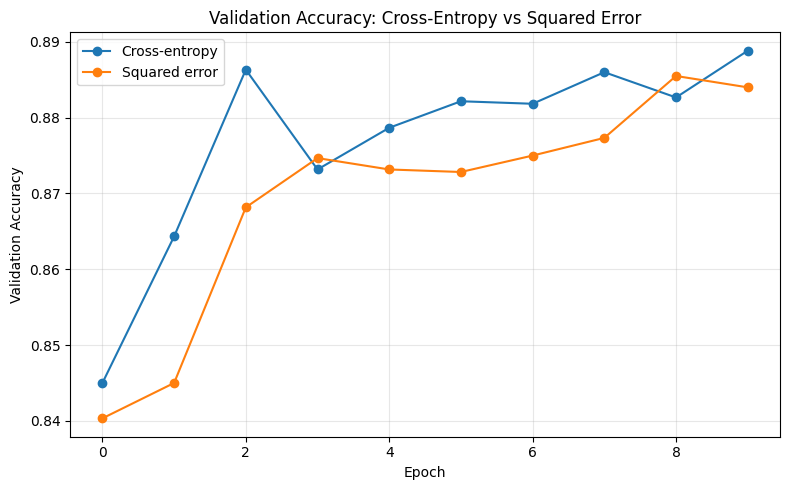

In [19]:
plt.figure(figsize=(8, 5))

plt.plot(
    loss_results["cross_entropy"]["history"]["val_acc"],
    marker="o",
    label="Cross-entropy"
)

plt.plot(
    loss_results["squared_error"]["history"]["val_acc"],
    marker="o",
    label="Squared error"
)

plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.title("Validation Accuracy: Cross-Entropy vs Squared Error")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("loss_comparison_val_accuracy.png", dpi=150, bbox_inches="tight")
plt.show()

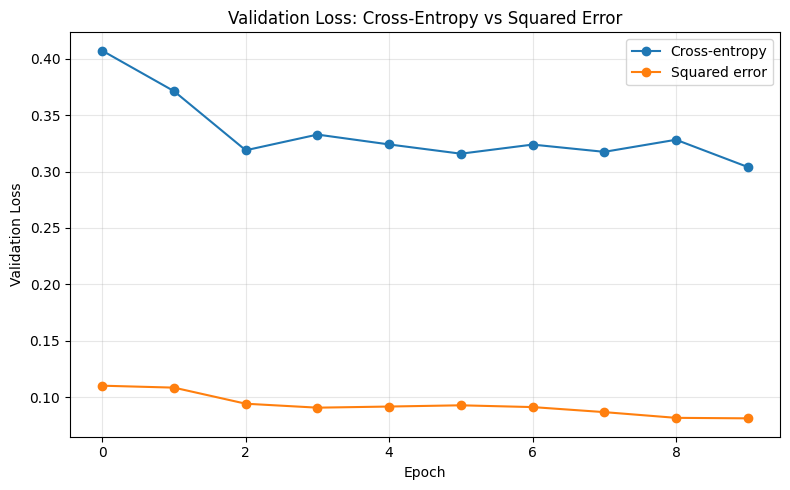

In [20]:
plt.figure(figsize=(8, 5))

plt.plot(
    loss_results["cross_entropy"]["history"]["val_loss"],
    marker="o",
    label="Cross-entropy"
)

plt.plot(
    loss_results["squared_error"]["history"]["val_loss"],
    marker="o",
    label="Squared error"
)

plt.xlabel("Epoch")
plt.ylabel("Validation Loss")
plt.title("Validation Loss: Cross-Entropy vs Squared Error")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("loss_comparison_val_loss.png", dpi=150, bbox_inches="tight")
plt.show()

In [21]:
run = wandb.init(project="atri-fashion-mnist", name="q8_loss_comparison")

run.log({
    "cross_entropy_test_acc": loss_results["cross_entropy"]["test_acc"],
    "cross_entropy_test_loss": loss_results["cross_entropy"]["test_loss"],
    "squared_error_test_acc": loss_results["squared_error"]["test_acc"],
    "squared_error_test_loss": loss_results["squared_error"]["test_loss"],
    "val_accuracy_comparison": wandb.Image("loss_comparison_val_accuracy.png"),
    "val_loss_comparison": wandb.Image("loss_comparison_val_loss.png")
})

run.finish()

cross_entropy_test_acc,▁
cross_entropy_test_loss,▁
squared_error_test_acc,▁
squared_error_test_loss,▁
cross_entropy_test_acc,0.8749
cross_entropy_test_loss,0.35184
squared_error_test_acc,0.8725
squared_error_test_loss,0.09227


The same model configuration was trained using two different loss functions: cross-entropy loss and squared error loss. To make the comparison fair, the architecture, optimizer, learning rate, batch size, activation function, initialization method, weight decay, and number of epochs were kept the same.

The cross-entropy model achieved a final validation accuracy of **0.8888** and a test accuracy of **0.8749**. The squared error model achieved a final validation accuracy of **0.8840** and a test accuracy of **0.8725**.

The validation accuracy curves show that both losses were able to train the model, but cross-entropy performed slightly better. This is expected because cross-entropy is more suitable for multi-class classification. It directly encourages the model to assign high probability to the correct class, whereas squared error treats the output more like a regression target.

The numerical loss values of cross-entropy and squared error should not be directly compared because they are computed on different scales. Therefore, validation accuracy and test accuracy are more useful for comparing the two losses.

Overall, cross-entropy is preferred for this classification task because it gave the best validation and test accuracy.

## Question 10: Recommendations for MNIST

The Fashion-MNIST sweep showed that the best-performing models generally used Xavier initialization, adaptive optimizers, tanh/ReLU activations, and avoided very high weight decay. Several poor runs were caused by weak combinations such as random initialization, high weight decay, small hidden layers, or slow learning rates.

Based on these observations, only three configurations are selected for MNIST. The goal is to check whether the learnings from Fashion-MNIST transfer to MNIST.

In [22]:
from keras.datasets import mnist
import numpy as np
import pandas as pd
import wandb

# Load MNIST
(X_mnist_train, y_mnist_train), (X_mnist_test, y_mnist_test) = mnist.load_data()

# Flatten and normalize
X_mnist_train = X_mnist_train.reshape(X_mnist_train.shape[0], -1) / 255.0
X_mnist_test = X_mnist_test.reshape(X_mnist_test.shape[0], -1) / 255.0

# Train-validation split
rng = np.random.default_rng(42)
indices = rng.permutation(X_mnist_train.shape[0])

val_size = int(0.10 * X_mnist_train.shape[0])

val_idx = indices[:val_size]
train_idx = indices[val_size:]

X_mnist_tr = X_mnist_train[train_idx]
y_mnist_tr = y_mnist_train[train_idx]

X_mnist_val = X_mnist_train[val_idx]
y_mnist_val = y_mnist_train[val_idx]

print("MNIST train:", X_mnist_tr.shape, y_mnist_tr.shape)
print("MNIST val:  ", X_mnist_val.shape, y_mnist_val.shape)
print("MNIST test: ", X_mnist_test.shape, y_mnist_test.shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
MNIST train: (54000, 784) (54000,)
MNIST val:   (6000, 784) (6000,)
MNIST test:  (10000, 784) (10000,)


In [23]:
mnist_configs = [
    {
        "name": "mnist_cfg1_best_fashion_transfer",
        "hidden_layers": [128, 128, 128, 128],
        "activation": "tanh",
        "optimizer": "rmsprop",
        "learning_rate": 0.001,
        "batch_size": 64,
        "weight_init": "xavier",
        "weight_decay": 0.0005,
        "epochs": 10
    },
    {
        "name": "mnist_cfg2_tanh_nadam",
        "hidden_layers": [128, 128, 128, 128, 128],
        "activation": "tanh",
        "optimizer": "nadam",
        "learning_rate": 0.0001,
        "batch_size": 16,
        "weight_init": "xavier",
        "weight_decay": 0.0,
        "epochs": 10
    },
    {
        "name": "mnist_cfg3_relu_adam",
        "hidden_layers": [128, 128, 128],
        "activation": "relu",
        "optimizer": "adam",
        "learning_rate": 0.001,
        "batch_size": 64,
        "weight_init": "xavier",
        "weight_decay": 0.0005,
        "epochs": 10
    }
]

In [24]:
mnist_results = []

for cfg in mnist_configs:
    print("\nRunning:", cfg["name"])

    run = wandb.init(
        project="atri-fashion-mnist",
        name=cfg["name"],
        group="q10_mnist_recommendations",
        config=cfg,
        reinit=True
    )

    model = NumpyMLP(
        input_size=784,
        hidden_layers=cfg["hidden_layers"],
        output_size=10,
        activation=cfg["activation"],
        weight_init=cfg["weight_init"],
        seed=42
    )

    history = model.fit(
        X_mnist_tr,
        y_mnist_tr,
        X_val=X_mnist_val,
        y_val=y_mnist_val,
        epochs=cfg["epochs"],
        batch_size=cfg["batch_size"],
        optimizer=cfg["optimizer"],
        lr=cfg["learning_rate"],
        weight_decay=cfg["weight_decay"],
        wandb_run=run,
        verbose=True
    )

    train_loss, train_acc = model.evaluate(
        X_mnist_tr,
        y_mnist_tr,
        weight_decay=cfg["weight_decay"]
    )

    val_loss, val_acc = model.evaluate(
        X_mnist_val,
        y_mnist_val,
        weight_decay=cfg["weight_decay"]
    )

    test_loss, test_acc = model.evaluate(
        X_mnist_test,
        y_mnist_test,
        weight_decay=cfg["weight_decay"]
    )

    row = {
        "Configuration": cfg["name"],
        "Hidden Layers": str(cfg["hidden_layers"]),
        "Activation": cfg["activation"],
        "Optimizer": cfg["optimizer"],
        "Learning Rate": cfg["learning_rate"],
        "Batch Size": cfg["batch_size"],
        "Weight Init": cfg["weight_init"],
        "Weight Decay": cfg["weight_decay"],
        "Epochs": cfg["epochs"],
        "Train Accuracy": train_acc,
        "Validation Accuracy": val_acc,
        "Test Accuracy": test_acc
    }

    mnist_results.append(row)

    run.log({
        "mnist_train_acc": train_acc,
        "mnist_val_acc": val_acc,
        "mnist_test_acc": test_acc,
        "mnist_train_loss": train_loss,
        "mnist_val_loss": val_loss,
        "mnist_test_loss": test_loss
    })

    run.finish()

mnist_results_df = pd.DataFrame(mnist_results)
mnist_results_df


Running: mnist_cfg1_best_fashion_transfer


wandb: WARNING Using a boolean value for 'reinit' is deprecated. Use 'return_previous' or 'finish_previous' instead.


Epoch 01/10 | train_loss=0.1877 | train_acc=0.9435 | val_loss=0.2106 | val_acc=0.9332
Epoch 02/10 | train_loss=0.0973 | train_acc=0.9704 | val_loss=0.1295 | val_acc=0.9632
Epoch 03/10 | train_loss=0.0704 | train_acc=0.9782 | val_loss=0.1187 | val_acc=0.9653
Epoch 04/10 | train_loss=0.0515 | train_acc=0.9842 | val_loss=0.1063 | val_acc=0.9693
Epoch 05/10 | train_loss=0.0479 | train_acc=0.9844 | val_loss=0.1054 | val_acc=0.9702
Epoch 06/10 | train_loss=0.0271 | train_acc=0.9919 | val_loss=0.0886 | val_acc=0.9760
Epoch 07/10 | train_loss=0.0257 | train_acc=0.9921 | val_loss=0.1051 | val_acc=0.9732
Epoch 08/10 | train_loss=0.0233 | train_acc=0.9927 | val_loss=0.1104 | val_acc=0.9727
Epoch 09/10 | train_loss=0.0158 | train_acc=0.9951 | val_loss=0.1052 | val_acc=0.9747
Epoch 10/10 | train_loss=0.0135 | train_acc=0.9958 | val_loss=0.1035 | val_acc=0.9757


epoch,▁▂▃▃▄▅▆▆▇█
mnist_test_acc,▁
mnist_test_loss,▁
mnist_train_acc,▁
mnist_train_loss,▁
mnist_val_acc,▁
mnist_val_loss,▁
train_acc,▁▅▆▆▆▇████
train_loss,█▄▃▃▂▂▁▁▁▁
val_acc,▁▆▆▇▇██▇██
+1,...



Running: mnist_cfg2_tanh_nadam


...

epoch,▁▂▃▃▄▅▆▆▇█
mnist_test_acc,▁
mnist_test_loss,▁
mnist_train_acc,▁
mnist_train_loss,▁
mnist_val_acc,▁
mnist_val_loss,▁
train_acc,▁▃▅▅▆▇▇▇██
train_loss,█▆▄▄▃▂▂▂▁▁
val_acc,▁▄▅▆▇█████
+1,...



Running: mnist_cfg3_relu_adam


Epoch 01/10 | train_loss=0.1118 | train_acc=0.9657 | val_loss=0.1378 | val_acc=0.9565
Epoch 02/10 | train_loss=0.0760 | train_acc=0.9762 | val_loss=0.1143 | val_acc=0.9665
Epoch 03/10 | train_loss=0.0451 | train_acc=0.9866 | val_loss=0.0903 | val_acc=0.9738
Epoch 04/10 | train_loss=0.0368 | train_acc=0.9889 | val_loss=0.0966 | val_acc=0.9747
Epoch 05/10 | train_loss=0.0347 | train_acc=0.9887 | val_loss=0.1038 | val_acc=0.9728
Epoch 06/10 | train_loss=0.0304 | train_acc=0.9903 | val_loss=0.1014 | val_acc=0.9743
Epoch 07/10 | train_loss=0.0191 | train_acc=0.9939 | val_loss=0.0990 | val_acc=0.9753
Epoch 08/10 | train_loss=0.0233 | train_acc=0.9923 | val_loss=0.1112 | val_acc=0.9738
Epoch 09/10 | train_loss=0.0241 | train_acc=0.9918 | val_loss=0.1185 | val_acc=0.9728
Epoch 10/10 | train_loss=0.0221 | train_acc=0.9925 | val_loss=0.1093 | val_acc=0.9738


epoch,▁▂▃▃▄▅▆▆▇█
mnist_test_acc,▁
mnist_test_loss,▁
mnist_train_acc,▁
mnist_train_loss,▁
mnist_val_acc,▁
mnist_val_loss,▁
train_acc,▁▄▆▇▇▇██▇█
train_loss,█▅▃▂▂▂▁▁▁▁
val_acc,▁▅▇█▇██▇▇▇
+1,...


,Configuration,Hidden Layers,Activation,Optimizer,Learning Rate,Batch Size,Weight Init,Weight Decay,Epochs,Train Accuracy,Validation Accuracy,Test Accuracy
0,mnist_cfg1_best_fashion_transfer,"[128, 128, 128, 128]",tanh,rmsprop,0.0010,64,xavier,0.0005,10,0.995759,0.975667,0.9749
1,mnist_cfg2_tanh_nadam,"[128, 128, 128, 128, 128]",tanh,nadam,0.0001,16,xavier,0.0000,10,0.990704,0.971500,0.9740
2,mnist_cfg3_relu_adam,"[128, 128, 128]",relu,adam,0.0010,64,xavier,0.0005,10,0.992481,0.973833,0.9750


In [25]:
mnist_results_df.to_csv("mnist_q10_results.csv", index=False)

print(mnist_results_df[[
    "Configuration",
    "Activation",
    "Optimizer",
    "Learning Rate",
    "Batch Size",
    "Weight Decay",
    "Validation Accuracy",
    "Test Accuracy"
]])

                      Configuration Activation Optimizer  Learning Rate  \
0  mnist_cfg1_best_fashion_transfer       tanh   rmsprop         0.0010   
1             mnist_cfg2_tanh_nadam       tanh     nadam         0.0001   
2              mnist_cfg3_relu_adam       relu      adam         0.0010   

   Batch Size  Weight Decay  Validation Accuracy  Test Accuracy  
0          64        0.0005             0.975667         0.9749  
1          16        0.0000             0.971500         0.9740  
2          64        0.0005             0.973833         0.9750  


### Final Recommendation

If only three configurations could be tested on MNIST, I would choose:

1. **Tanh + RMSProp + Xavier**, because this was the best Fashion-MNIST configuration and gave the highest MNIST validation accuracy.
2. **Tanh + Nadam + Xavier**, because Nadam was also strong in the Fashion-MNIST sweep and gives a useful comparison with RMSProp.
3. **ReLU + Adam + Xavier**, because ReLU and Adam are a strong standard combination, and this configuration gave the highest MNIST test accuracy among the three runs.

Among the three, the validation-best model is `mnist_cfg1_best_fashion_transfer`, while the test-best model is `mnist_cfg3_relu_adam`.